# Files Upload

In [1]:
import os
from google.colab import files

# Prompt user to upload a file via Colab's interface
print("Select a file to upload:")
uploaded = files.upload()

if uploaded:
    # Get the first uploaded file
    file_name = list(uploaded.keys())[0]
    file_content = uploaded[file_name]

    # Extract filename without extension
    file_base_name, file_extension = os.path.splitext(file_name)

    # Save the file to the Colab file system
    with open(f'/content/{file_name}', 'wb') as f:
        f.write(file_content)
    prefix = file_base_name
    print(f"File saved to /content/{file_name}")
else:
    print("No file uploaded.")

Select a file to upload:


Saving Normal_24-6-25_naroda-to-dau.zip to Normal_24-6-25_naroda-to-dau.zip
File saved to /content/Normal_24-6-25_naroda-to-dau.zip


# Merge all Sensor CSV files into single CSV file

In [2]:
import zipfile
import os
import pandas as pd
from datetime import datetime, timezone, timedelta

# Paths
zip_path = f"{prefix}.zip"
extract_dir = "sensor_data"
output_csv = f"{prefix}_merged_raw_data.csv"

# Extract ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Convert nanoseconds to IST
def convert_ns_to_ist(ns):
    dt_utc = datetime.fromtimestamp(ns / 1e9, tz=timezone.utc)
    return dt_utc.astimezone(timezone(timedelta(hours=5, minutes=30)))

# Read sensor files and prepare them
def load_sensor_csv(path, value_cols, prefix):
    df = pd.read_csv(path)
    df = df.rename(columns=lambda x: x.strip())
    df = df[['time'] + value_cols]
    df['datetime_ist'] = df['time'].apply(convert_ns_to_ist)
    df.set_index('datetime_ist', inplace=True)
    df = df.drop(columns=['time'])
    df.columns = [f"{prefix}_{col.lower()}" for col in df.columns]

    # Special handling for Location data
    if prefix == 'Location':
        if 'Location_speed' in df.columns:
            df['Location_speed'] *= 3.6  # Convert m/s to km/h
            df = df[df['Location_speed'] >= 0]

        if 'Location_bearingaccuracy' in df.columns:
            invalid_mask = df['Location_bearingaccuracy'] < 0
            if 'Location_bearing' in df.columns:
                df.loc[invalid_mask, 'Location_bearing'] = float('nan')
            df = df.drop(columns=['Location_bearingaccuracy'])

    return df

# Find sensor files
sensor_files = {'Accelerometer': None, 'Gyroscope': None, 'Magnetometer': None, 'Location': None, 'Gravity': None, 'Orientation': None}
for root, _, files in os.walk(extract_dir):
    for file in files:
        f = file.lower()
        path = os.path.join(root, file)
        if "accelerometer.csv" in f:
            sensor_files['Accelerometer'] = path
        elif "gyroscope.csv" in f:
            sensor_files['Gyroscope'] = path
        elif "magnetometer.csv" in f:
            sensor_files['Magnetometer'] = path
        elif "location.csv" in f:
            sensor_files['Location'] = path
        elif "gravity.csv" in f:
            sensor_files['Gravity'] = path
        elif "orientation.csv" in f:
            sensor_files['Orientation'] = path

# Load raw Location data to preserve original time range
raw_loc_df = pd.read_csv(sensor_files['Location'])
raw_loc_df = raw_loc_df.rename(columns=lambda x: x.strip())
raw_loc_df['datetime_ist'] = raw_loc_df['time'].apply(convert_ns_to_ist)
raw_loc_df.set_index('datetime_ist', inplace=True)

# Load and process each sensor
accel_df = load_sensor_csv(sensor_files['Accelerometer'], ['x', 'y', 'z'], 'Accelerometer')
grav_df = load_sensor_csv(sensor_files['Gravity'], ['x', 'y', 'z'], 'Gravity')
gyro_df = load_sensor_csv(sensor_files['Gyroscope'], ['x', 'y', 'z'], 'Gyroscope')
mag_df = load_sensor_csv(sensor_files['Magnetometer'], ['x', 'y', 'z'], 'Magnetometer')
loc_df = load_sensor_csv(sensor_files['Location'], ['latitude', 'longitude', 'speed', 'bearing', 'bearingAccuracy','horizontalAccuracy'], 'Location')
ori_df = load_sensor_csv(sensor_files['Orientation'], ['qw', 'qx', 'qy', 'qz'], 'Orientation')

# Define common time index (40Hz = 25ms interval)
start_time = max(df.index.min() for df in [accel_df, grav_df, gyro_df, mag_df, raw_loc_df, ori_df])
end_time = min(df.index.max() for df in [accel_df, grav_df, gyro_df, mag_df, raw_loc_df, ori_df])
common_index = pd.date_range(start=start_time, end=end_time, freq='25ms')

# Function to align and interpolate sensor data to common index
def reindex_and_interpolate(df, common_index, method='nearest'):
    df = df.reindex(common_index, method=method)
    df = df.interpolate(method='time', limit_direction='both')
    return df

# Apply to all high-frequency mobility sensors
accel_df = reindex_and_interpolate(accel_df, common_index)
grav_df = reindex_and_interpolate(grav_df, common_index)
gyro_df = reindex_and_interpolate(gyro_df, common_index)
mag_df = reindex_and_interpolate(mag_df, common_index)
ori_df = reindex_and_interpolate(ori_df, common_index)

# Merge high-frequency sensor data
merged = pd.concat([accel_df, grav_df, gyro_df, mag_df, ori_df], axis=1)

# Reindex and clean location data
loc_df = loc_df.reindex(common_index, method='nearest')
loc_df = loc_df.interpolate(method='time', limit_direction='both')
loc_df['Location_speed'] = loc_df['Location_speed'].ffill().rolling(window=3, center=True, min_periods=1).mean()
loc_df = loc_df.ffill().bfill()

# Combine all data
merged = pd.concat([merged, loc_df], axis=1)

# Drop rows where high-frequency sensor data is still missing
merged = merged.dropna(subset=[col for col in merged.columns if not col.startswith('Location_')])

# Save to CSV
merged.reset_index(inplace=True)
merged.rename(columns={'index': 'datetime_ist'}, inplace=True)
merged.to_csv(output_csv, index=False)
print(f"Merged data saved to {output_csv}")

Merged data saved to Normal_24-6-25_naroda-to-dau_merged_raw_data.csv


# Orientation independent

In [3]:
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R

def rotate_vector_with_quaternion(vector, qw, qx, qy, qz):
    try:
        r = R.from_quat([qx, qy, qz, qw])
        return r.apply(vector)
    except Exception:
        return [np.nan, np.nan, np.nan]

def rotate_to_vehicle_heading(vector, bearing_deg):
    try:
        # Convert bearing to radians (Z-axis rotation)
        theta = np.deg2rad(bearing_deg)
        cos_theta = np.cos(theta)
        sin_theta = np.sin(theta)

        # Rotation around Z-axis
        Rz = np.array([
            [cos_theta, -sin_theta, 0],
            [sin_theta,  cos_theta, 0],
            [0,          0,         1]
        ])
        return np.dot(Rz, vector)
    except Exception:
        return [np.nan, np.nan, np.nan]

# Load dataset
df = pd.read_csv(f"{prefix}_merged_raw_data.csv")

accel_vehicle = []
gyro_vehicle = []

for i in range(len(df)):
    try:
        # Sensor readings
        ax, ay, az = df.loc[i, ['Accelerometer_x', 'Accelerometer_y', 'Accelerometer_z']]
        gx, gy, gz = df.loc[i, ['Gyroscope_x', 'Gyroscope_y', 'Gyroscope_z']]
        qw, qx, qy, qz = df.loc[i, ['Orientation_qw', 'Orientation_qx', 'Orientation_qy', 'Orientation_qz']]
        bearing = df.loc[i, 'Location_bearing']

        # Step 1: Rotate by quaternion to world frame
        accel_world = rotate_vector_with_quaternion([ax, ay, az], qw, qx, qy, qz)
        gyro_world = rotate_vector_with_quaternion([gx, gy, gz], qw, qx, qy, qz)

        # Step 2: Rotate around Z-axis to align to vehicle forward direction
        accel_rot = rotate_to_vehicle_heading(accel_world, bearing)
        gyro_rot = rotate_to_vehicle_heading(gyro_world, bearing)

        accel_vehicle.append(accel_rot)
        gyro_vehicle.append(gyro_rot)

    except Exception:
        accel_vehicle.append([np.nan, np.nan, np.nan])
        gyro_vehicle.append([np.nan, np.nan, np.nan])

# Add transformed values
df[['Accel_vehicle_x', 'Accel_vehicle_y', 'Accel_vehicle_z']] = pd.DataFrame(accel_vehicle, index=df.index)
df[['Gyro_vehicle_x', 'Gyro_vehicle_y', 'Gyro_vehicle_z']] = pd.DataFrame(gyro_vehicle, index=df.index)

# Save output
df.to_csv(f"{prefix}_vehicle_frame_orientation_independent.csv", index=False)
print(f"Saved transformed data to '{prefix}_vehicle_frame_orientation_independent.csv'")

Saved transformed data to 'Normal_24-6-25_naroda-to-dau_vehicle_frame_orientation_independent.csv'


# DBSCAN

In [4]:
import pandas as pd
import numpy as np
import math
from sklearn.cluster import DBSCAN

# Load the data
file_path = f"{prefix}_vehicle_frame_orientation_independent.csv"
df = pd.read_csv(file_path)

# Filter invalid GPS points
valid_df = df[(df['Location_horizontalaccuracy'] > 0) & (df['Location_speed'] >= 0)].copy()

# Compute eps = mean + 2*std of horizontal accuracy
mean_accuracy = valid_df['Location_horizontalaccuracy'].mean()
std_accuracy = valid_df['Location_horizontalaccuracy'].std()
eps_meters = mean_accuracy + 2 * std_accuracy
print("mean accuracy: ",mean_accuracy)
print("std accuracy: ",std_accuracy)
# Custom haversine distance function in meters
def mydistance(origin, destination):
    lat1, lon1 = origin
    lat2, lon2 = destination
    radius = 6371000  # meters (Earth radius)

    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return radius * c

# Prepare data for clustering
location_data = valid_df[['Location_latitude', 'Location_longitude']].values

print("EPS value (meters):", eps_meters)

# Run DBSCAN
db = DBSCAN(eps=eps_meters, min_samples=160, metric=mydistance)
labels = db.fit_predict(location_data)

# Attach cluster labels to data
valid_df['cluster'] = labels

# Extract stop points (clusters excluding noise -1)
stop_points = valid_df[valid_df['cluster'] != -1].copy()

# Compute cluster-wise stop centroids and speed summary
stop_centroids = stop_points.groupby('cluster').agg({
    'Location_latitude': 'mean',
    'Location_longitude': 'mean',
    'Location_speed': ['mean', 'min', 'max']
}).reset_index()

# Flatten multi-index columns
stop_centroids.columns = ['cluster', 'latitude', 'longitude', 'mean_speed', 'min_speed', 'max_speed']

# Save outputs
clustered_output_path = f"{prefix}_stop_cluster.csv"
centroid_output_path = f"{prefix}_stop_centroids.csv"
valid_df.to_csv(clustered_output_path, index=False)
stop_centroids.to_csv(centroid_output_path, index=False)

print(f"Number of stop clusters detected: {len(stop_centroids)}")
print(f"Clustered data saved to: {clustered_output_path}")
print(f"Stop centroids with speed saved to: {centroid_output_path}")

mean accuracy:  6.675415708827498
std accuracy:  4.789479662208894
EPS value (meters): 16.254375033245285
Number of stop clusters detected: 35
Clustered data saved to: Normal_24-6-25_naroda-to-dau_stop_cluster.csv
Stop centroids with speed saved to: Normal_24-6-25_naroda-to-dau_stop_centroids.csv


In [5]:
import pandas as pd
import folium

# Load enhanced stop centroids file
stop_centroids = pd.read_csv(f"{prefix}_stop_centroids.csv")

# Create base map centered on average location
map_center = [stop_centroids['latitude'].mean(), stop_centroids['longitude'].mean()]
stop_map = folium.Map(location=map_center, zoom_start=15)

# Add markers with popup showing speed details
for _, row in stop_centroids.iterrows():
    popup_text = (
        f"<b>Stop Cluster:</b> {int(row['cluster'])}<br>"
        f"<b>Lat:</b> {row['latitude']:.6f}<br>"
        f"<b>Lon:</b> {row['longitude']:.6f}<br>"
        f"<b>Mean Speed:</b> {row['mean_speed']:.2f} km/h<br>"
        f"<b>Min Speed:</b> {row['min_speed']:.2f} km/h<br>"
        f"<b>Max Speed:</b> {row['max_speed']:.2f} km/h"
    )
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=folium.Popup(popup_text, max_width=300),
        icon=folium.Icon(color='blue', icon='pause', prefix='fa')
    ).add_to(stop_map)

# Save map to HTML
stop_map.save(f"{prefix}_stop_map.html")

# Plot acceleration

In [6]:
!pip install streamlit
!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 76.4 MB/s eta 0:00:00


In [7]:
%%writefile stoppage_cluster_plot.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(layout="wide")
st.title("DBSCAN Cluster Acceleration Viewer")

# === File Upload ===
uploaded_file = st.file_uploader("Upload dbscan_clustered_output.csv", type=["csv"])

if uploaded_file:
    df = pd.read_csv(uploaded_file)

    # Convert datetime if present
    if 'datetime_ist' in df.columns:
        df['datetime_ist'] = pd.to_datetime(df['datetime_ist'])
    else:
        df['datetime_ist'] = pd.date_range(start='2024-01-01', periods=len(df), freq='1S')  # fallback

    # Filter valid clusters
    stop_clusters = sorted(df['cluster'].unique())
    stop_clusters = [c for c in stop_clusters if c != -1]

    if not stop_clusters:
        st.warning("No valid (non -1) clusters found.")
        st.stop()

    if 'cluster_index' not in st.session_state:
        st.session_state.cluster_index = 0

    # === Manual Input for Cluster Navigation ===
    st.sidebar.header("Jump to Cluster")
    selected_cluster = st.sidebar.selectbox("Select Cluster", stop_clusters, index=st.session_state.cluster_index)

    # Sync state when dropdown changes
    if selected_cluster != stop_clusters[st.session_state.cluster_index]:
        st.session_state.cluster_index = stop_clusters.index(selected_cluster)

    # === Navigation Buttons ===
    col1, col2, col3 = st.columns(3)
    with col1:
        if st.button("⬅️ Previous"):
            st.session_state.cluster_index = max(0, st.session_state.cluster_index - 1)
    with col3:
        if st.button("Next ➡️"):
            st.session_state.cluster_index = min(len(stop_clusters) - 1, st.session_state.cluster_index + 1)

    # === Show Current Cluster Data ===
    current_cluster = stop_clusters[st.session_state.cluster_index]
    st.markdown(f"### Cluster: `{current_cluster}` ({st.session_state.cluster_index + 1} of {len(stop_clusters)})")

    cluster_df = df[df['cluster'] == current_cluster]

    if cluster_df.empty:
        st.warning("No data found for this cluster.")
    else:
        # Plotting
        fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

        axs[0].plot(cluster_df['datetime_ist'], cluster_df['Accel_vehicle_x'], color='red')
        axs[0].set_ylabel("Accel X")
        axs[0].grid(True)

        axs[1].plot(cluster_df['datetime_ist'], cluster_df['Accel_vehicle_y'], color='green')
        axs[1].set_ylabel("Accel Y")
        axs[1].grid(True)

        axs[2].plot(cluster_df['datetime_ist'], cluster_df['Accel_vehicle_z'], color='blue')
        axs[2].set_ylabel("Accel Z")
        axs[2].set_xlabel("Time")
        axs[2].grid(True)

        plt.suptitle(f"Acceleration Plot for Cluster {current_cluster}")
        plt.tight_layout()
        st.pyplot(fig)

Writing stoppage_cluster_plot.py


In [8]:
from pyngrok import ngrok
import threading
import time
import os
from google.colab import userdata

# Get ngrok authtoken from Colab secrets
# NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
NGROK_AUTH_TOKEN = '2ycgej6RJ43GewbmJIPUlpFGeyj_37YWHBYRZxmthx1236Y9Y'
# Authenticate ngrok
if NGROK_AUTH_TOKEN:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
else:
    print("NGROK_AUTH_TOKEN not found in Colab secrets. Please add it.")

# Start the streamlit app in background
def run():
    os.system('streamlit run stoppage_cluster_plot.py')

threading.Thread(target=run).start()
time.sleep(5)

# Get public URL
try:
    public_url = ngrok.connect(8501)
    print("Streamlit App URL:", public_url)
except Exception as e:
    print(f"Error connecting to ngrok: {e}")

Streamlit App URL: NgrokTunnel: "https://c6bb-34-125-210-6.ngrok-free.app" -> "http://localhost:8501"


In [9]:
from pyngrok import ngrok

print("Stopping all ngrok tunnels...")
ngrok.kill()
print("All ngrok tunnels stopped.")

Stopping all ngrok tunnels...
All ngrok tunnels stopped.


# Potholes & Bump

In [10]:
import pandas as pd
import numpy as np
import pywt
from collections import Counter

# Load the CSV file
data = pd.read_csv(f"{prefix}_stop_cluster.csv")

# Filter rows where cluster != -1
filtered_data = data[data['cluster'] != -1]

# Group data by cluster
grouped_data = filtered_data.groupby('cluster')

# Parameters
roughness_threshold = 2.0      # Road roughness (std dev)
coefficient_threshold = 0.01   # Threshold for anomaly detection

anomaly_results = []

def pad_to_power_of_two(arr):
    """Pad array with zeros to next power of 2."""
    n = len(arr)
    next_pow2 = 2 ** int(np.ceil(np.log2(n)))
    pad_length = next_pow2 - n
    return np.pad(arr, (0, pad_length), mode='constant'), n  # return original length

# Process each cluster
for cluster_id, group in grouped_data:
    acceleration_z = group['Accel_vehicle_z'].values
    std_dev = np.std(acceleration_z)

    # Only process smooth road segments
    if std_dev < roughness_threshold:
        # Step 1: Pad to next 2^n
        padded_signal, original_length = pad_to_power_of_two(acceleration_z)

        # Step 2: 2-level wavelet decomposition
        coeffs = pywt.wavedec(padded_signal, 'db2', level=2)
        W1 = coeffs[2]  # level-1 details (fine)
        W2 = coeffs[1]  # level-2 details (coarse)

        # Step 3: Interpolate W1, W2 to original length
        W1 = np.interp(np.linspace(0, len(W1) - 1, original_length), np.arange(len(W1)), W1)
        W2 = np.interp(np.linspace(0, len(W2) - 1, original_length), np.arange(len(W2)), W2)

        # Step 4: Scale-space filter: Ω²(k) = W1 × W2
        omega_squared = W1 * W2

        # Step 5: Keep values where |Ω²(k)| ≥ |W1(k)|
        W_new = np.where(np.abs(omega_squared) >= np.abs(W1), omega_squared, 0)

        # Step 6: Detect and classify anomalies
        for i, value in enumerate(W_new):
            if abs(value) >= coefficient_threshold:
                anomaly_type = 'bump' if value > 0 else 'pothole'
                time = group.iloc[i]['datetime_ist']
                anomaly_results.append({
                    'cluster': cluster_id,
                    'time': time,
                    'anomaly_type': anomaly_type,
                    'coefficient': value
                })

# Summarize cluster behavior
behavior_results = []
for cluster_id in grouped_data.groups.keys():
    anomalies = [a['anomaly_type'] for a in anomaly_results if a['cluster'] == cluster_id]
    if not anomalies:
        label = "stoppage"
    else:
        most_common = Counter(anomalies).most_common(1)[0][0]
        label = most_common
    behavior_results.append({'cluster': cluster_id, 'behavior': label})

# Save output
behavior_df = pd.DataFrame(behavior_results)
behavior_df.to_csv(f'{prefix}_cluster_behavior.csv', index=False)

print(f"Cluster behavior summary saved to '{prefix}_cluster_behavior.csv'.")

Cluster behavior summary saved to 'Normal_24-6-25_naroda-to-dau_cluster_behavior.csv'.


plotting

In [11]:
import matplotlib.pyplot as plt
import os

# Create folder for plots
os.makedirs("W_new_plots", exist_ok=True)

# Re-process each cluster for plotting
for cluster_id, group in grouped_data:
    acceleration_z = group['Accel_vehicle_z'].values
    std_dev = np.std(acceleration_z)

    if std_dev < roughness_threshold:
        padded_signal, original_length = pad_to_power_of_two(acceleration_z)

        coeffs = pywt.wavedec(padded_signal, 'db2', level=2)
        W1 = coeffs[2]
        W2 = coeffs[1]
        W1 = np.interp(np.linspace(0, len(W1) - 1, original_length), np.arange(len(W1)), W1)
        W2 = np.interp(np.linspace(0, len(W2) - 1, original_length), np.arange(len(W2)), W2)
        omega_squared = W1 * W2
        W_new = np.where(np.abs(omega_squared) >= np.abs(W1), omega_squared, 0)

        # Create masks for bump and pothole points
        bump_indices = [i for i, val in enumerate(W_new) if val > coefficient_threshold]
        pothole_indices = [i for i, val in enumerate(W_new) if val < -coefficient_threshold]

        # Plot
        plt.figure(figsize=(10, 4))
        plt.plot(W_new, label='W_new', color='gray', linewidth=1)
        plt.scatter(bump_indices, W_new[bump_indices], color='green', label='Bump', s=20)
        plt.scatter(pothole_indices, W_new[pothole_indices], color='red', label='Pothole', s=20)
        plt.title(f'Filtered Signal (W_new) for Cluster {cluster_id}')
        plt.xlabel('Sample Index')
        plt.ylabel('Filtered Acceleration')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        # Save the plot
        plt.savefig(f'W_new_plots/cluster_{cluster_id}_W_new.png')
        plt.close()

print("✅ Plots saved in 'W_new_plots/' folder.")

✅ Plots saved in 'W_new_plots/' folder.


In [12]:
import pandas as pd

# Load the two CSV files
stop_centroids_df = pd.read_csv(f"{prefix}_stop_centroids.csv")
cluster_behavior_df = pd.read_csv(f"{prefix}_cluster_behavior.csv")

# Merge the two dataframes on the 'cluster' column
merged_df = pd.merge(stop_centroids_df, cluster_behavior_df, on='cluster', how='left')

# Save the merged dataframe to a new CSV file
merged_df.to_csv(f"{prefix}_merged_stop_data_with_behavior.csv", index=False)

print(f"Merged data saved to {prefix}_merged_stop_data_with_behavior.csv")

Merged data saved to Normal_24-6-25_naroda-to-dau_merged_stop_data_with_behavior.csv


In [13]:
import pandas as pd
import folium

# Load the merged data
merged_df = pd.read_csv(f"{prefix}_merged_stop_data_with_behavior.csv")

# Create a base map centered on the average location
map_center = [merged_df['latitude'].mean(), merged_df['longitude'].mean()]
behavior_map = folium.Map(location=map_center, zoom_start=15)

# Define color mapping for behaviors
color_map = {
    'pothole': 'red',
    'bump': 'blue',
    'stoppage': 'green',
    'unknown': 'gray' # Add a default color for any unexpected labels
}

# Add markers with behavior-based color and detailed popup
for _, row in merged_df.iterrows():
    popup_text = (
        f"<b>Cluster:</b> {int(row['cluster'])}<br>"
        f"<b>Lat:</b> {row['latitude']:.6f}<br>"
        f"<b>Lon:</b> {row['longitude']:.6f}<br>"
        f"<b>Mean Speed:</b> {row['mean_speed']:.2f} km/h<br>"
        f"<b>Min Speed:</b> {row['min_speed']:.2f} km/h<br>"
        f"<b>Max Speed:</b> {row['max_speed']:.2f} km/h<br>"
        f"<b>Behavior:</b> {row['behavior']}"
    )

    color = color_map.get(row['behavior'], 'gray')

    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=folium.Popup(popup_text, max_width=300),
        icon=folium.Icon(color=color, icon='circle')
    ).add_to(behavior_map)

# Save map
behavior_map.save(f"{prefix}_behavior_map.html")
print(f"Map saved as {prefix}_behavior_map.html")

Map saved as Normal_24-6-25_naroda-to-dau_behavior_map.html


DTW method

In [14]:
# view window and identify window index
import os
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt

# === PARAMETERS ===
WINDOW_SIZE = 30
HALF_WIN = WINDOW_SIZE // 2
THRESHOLD = 0.01
ROUGHNESS_LIMIT = 2.0
TEMPLATE_DIR = 'templates'

# === Ensure template directory exists ===
os.makedirs(TEMPLATE_DIR, exist_ok=True)

# === Load your clustered data ===
df = pd.read_csv(f"{prefix}_stop_cluster.csv")

# === Filter cluster != -1 ===
filtered_df = df[df['cluster'] != -1].reset_index(drop=True)
grouped = filtered_df.groupby('cluster')

# === Helper: Pad to power of 2 ===
def pad_to_pow2(signal):
    n = len(signal)
    next_pow = 2 ** int(np.ceil(np.log2(n)))
    return np.pad(signal, (0, next_pow - n), mode='constant'), n

# === Extract anomaly windows from W_new ===
anomaly_windows = []
metadata = []

for cluster_id, group in grouped:
    z = group['Accel_vehicle_z'].values
    std_dev = np.std(z)
    if std_dev > ROUGHNESS_LIMIT:
        continue

    padded_z, original_len = pad_to_pow2(z)
    coeffs = pywt.wavedec(padded_z, 'db2', level=2)
    W1 = coeffs[2]
    W2 = coeffs[1]

    # Interpolate to match original length
    W1 = np.interp(np.linspace(0, len(W1)-1, original_len), np.arange(len(W1)), W1)
    W2 = np.interp(np.linspace(0, len(W2)-1, original_len), np.arange(len(W2)), W2)
    omega_squared = W1 * W2
    W_new = np.where(np.abs(omega_squared) >= np.abs(W1), omega_squared, 0)

    for i in range(HALF_WIN, len(W_new) - HALF_WIN):
        if abs(W_new[i]) >= THRESHOLD:
            window = W_new[i - HALF_WIN:i + HALF_WIN]
            if len(window) == WINDOW_SIZE:
                anomaly_windows.append(window)
                metadata.append({'cluster_id': cluster_id, 'index': i})

print(f"Extracted {len(anomaly_windows)} anomaly windows")

# === Function to view any specific window ===
def view_window(index):
    if index < 0 or index >= len(anomaly_windows):
        print("Invalid index")
        return
    win = anomaly_windows[index]
    info = metadata[index]
    plt.figure(figsize=(6, 2))
    plt.plot(win, marker='o')
    plt.title(f"Window #{index} | Cluster {info['cluster_id']} | Sample idx: {info['index']}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === Function to manually label windows ===
def label_windows():
    for idx, win in enumerate(anomaly_windows):
        print(f"\n--- Window {idx} ---")
        view_window(idx)
        label = input("Label this window? (b=bump, p=pothole, s=skip, q=quit): ").strip().lower()
        if label == 'b':
            np.save(f'{TEMPLATE_DIR}/bump_{idx}.npy', win)
        elif label == 'p':
            np.save(f'{TEMPLATE_DIR}/pothole_{idx}.npy', win)
        elif label == 'q':
            print("Stopping labeling.")
            break
        else:
            print("Skipped.")

# === Function to auto label selected windows ===
def label_selected_windows():
    bump_indices = [100, 1100, 2200]
    pothole_indices = [1530, 140,1350]

    for idx in range(len(anomaly_windows)):
        win = anomaly_windows[idx]
        if idx in bump_indices:
            np.save(f'{TEMPLATE_DIR}/bump_{idx}.npy', win)
            print(f"Saved bump_{idx}.npy")
        elif idx in pothole_indices:
            np.save(f'{TEMPLATE_DIR}/pothole_{idx}.npy', win)
            print(f"Saved pothole_{idx}.npy")


# === USAGE ===
# To label manually:
# label_windows()

label_selected_windows()

# To view specific window:
# view_window(140)

Extracted 5334 anomaly windows
Saved bump_100.npy
Saved pothole_140.npy
Saved bump_1100.npy
Saved pothole_1350.npy
Saved pothole_1530.npy
Saved bump_2200.npy


In [15]:
# to create template for DTW
import os
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt
from zipfile import ZipFile

# === PARAMETERS ===
WINDOW_SIZE = 30
HALF_WIN = WINDOW_SIZE // 2
THRESHOLD = 0.01
ROUGHNESS_LIMIT = 2.0
SPIKE_THRESHOLD_RATIO = 0.5
TEMPLATE_DIR = 'templates'
PLOT_DIR = os.path.join(TEMPLATE_DIR, 'plots')
ZIP_OUTPUT = 'templates_cleaned.zip'

# === Ensure directories exist ===
os.makedirs(TEMPLATE_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# === Load your clustered data ===
df = pd.read_csv(f"{prefix}_stop_cluster.csv")
filtered_df = df[df['cluster'] != -1].reset_index(drop=True)
grouped = filtered_df.groupby('cluster')

# === Helper: Pad to power of 2 ===
def pad_to_pow2(signal):
    n = len(signal)
    next_pow = 2 ** int(np.ceil(np.log2(n)))
    return np.pad(signal, (0, next_pow - n), mode='constant'), n

# === Clean spike noise ===
def clean_window(window, ratio=SPIKE_THRESHOLD_RATIO):
    max_val = np.max(np.abs(window))
    return np.where(np.abs(window) >= ratio * max_val, window, 0)

# === Extract anomaly windows from W_new ===
anomaly_windows = []
metadata = []

for cluster_id, group in grouped:
    z = group['Accel_vehicle_z'].values
    std_dev = np.std(z)
    if std_dev > ROUGHNESS_LIMIT:
        continue

    padded_z, original_len = pad_to_pow2(z)
    coeffs = pywt.wavedec(padded_z, 'db2', level=2)
    W1 = coeffs[2]
    W2 = coeffs[1]
    W1 = np.interp(np.linspace(0, len(W1)-1, original_len), np.arange(len(W1)), W1)
    W2 = np.interp(np.linspace(0, len(W2)-1, original_len), np.arange(len(W2)), W2)
    omega_squared = W1 * W2
    W_new = np.where(np.abs(omega_squared) >= np.abs(W1), omega_squared, 0)

    for i in range(HALF_WIN, len(W_new) - HALF_WIN):
        if abs(W_new[i]) >= THRESHOLD:
            window = W_new[i - HALF_WIN:i + HALF_WIN]
            if len(window) == WINDOW_SIZE:
                anomaly_windows.append(window)
                metadata.append({'cluster_id': cluster_id, 'index': i})

print(f"Extracted {len(anomaly_windows)} anomaly windows")

# === Auto label and clean selected windows ===
bump_indices = [100, 1100, 2200]
pothole_indices = [1530, 140,1350]

for idx in range(len(anomaly_windows)):
    win = anomaly_windows[idx]
    clean_win = clean_window(win)
    label = None

    if idx in bump_indices:
        label = 'bump'
    elif idx in pothole_indices:
        label = 'pothole'

    if label:
        np.save(f'{TEMPLATE_DIR}/{label}_{idx}.npy', clean_win)

        plt.figure(figsize=(6, 2))
        plt.plot(clean_win, marker='o')
        plt.title(f"{label.upper()} Template #{idx}")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f'{PLOT_DIR}/{label}_{idx}.png')
        plt.close()

# === Create zip file of templates and plots ===
with ZipFile(ZIP_OUTPUT, 'w') as zipf:
    for folder in [TEMPLATE_DIR, PLOT_DIR]:
        for root, _, files in os.walk(folder):
            for file in files:
                path = os.path.join(root, file)
                arcname = os.path.relpath(path, TEMPLATE_DIR)
                zipf.write(path, arcname)

print(f"All templates and plots saved and zipped to {ZIP_OUTPUT}")

Extracted 5334 anomaly windows
All templates and plots saved and zipped to templates_cleaned.zip


/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'plots/pothole_1350.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'plots/bump_100.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'plots/pothole_1530.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'plots/bump_1100.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'plots/pothole_140.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'plots/bump_2200.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)


In [16]:
!pip install fastdtw

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp312-cp312-linux_x86_64.whl size=567858 sha256=721b7014da66b8b81c5b9c62e5aaf226b9ca5f67a1dd4cc094ada610ea183223
  Stored in directory: /root/.cache/pip/wheels/ab/d0/26/b82cb0f49ae73e5e6bba4e8462fff2c9851d7bd2ec64f8891e
Successfully built fastdtw


In [17]:
import os
import numpy as np
import pandas as pd
import pywt
from fastdtw import fastdtw
from collections import defaultdict, Counter
import glob

# === PARAMETERS ===
WINDOW_SIZE = 30
HALF_WIN = WINDOW_SIZE // 2
THRESHOLD = 0.01
ROUGHNESS_LIMIT = 2.0
TEMPLATE_DIR = 'templates'
CSV_PATH = f"{prefix}_stop_cluster.csv"

# === Step 1: Load CSV and prepare data ===
df = pd.read_csv(CSV_PATH)
filtered_df = df[df['cluster'] != -1].reset_index(drop=True)
grouped = filtered_df.groupby('cluster')

# === Helper: Pad to next power of 2 ===
def pad_to_pow2(signal):
    n = len(signal)
    next_pow = 2 ** int(np.ceil(np.log2(n)))
    return np.pad(signal, (0, next_pow - n), mode='constant'), n

# === Helper: Normalize a window (zero mean, unit std) ===
def normalize_window(w):
    w = np.array(w)
    std = np.std(w)
    return (w - np.mean(w)) / (std + 1e-6) if std > 0 else w - np.mean(w)

# === Step 2: Extract anomaly windows using W_new ===
anomaly_windows = []
metadata = []

for cluster_id, group in grouped:
    z = group['Accel_vehicle_z'].values
    std_dev = np.std(z)
    if std_dev > ROUGHNESS_LIMIT:
        continue

    padded_z, original_len = pad_to_pow2(z)
    coeffs = pywt.wavedec(padded_z, 'db2', level=2)
    W1 = coeffs[2]
    W2 = coeffs[1]

    W1 = np.interp(np.linspace(0, len(W1)-1, original_len), np.arange(len(W1)), W1)
    W2 = np.interp(np.linspace(0, len(W2)-1, original_len), np.arange(len(W2)), W2)

    omega_squared = W1 * W2
    W_new = np.where(np.abs(omega_squared) >= np.abs(W1), omega_squared, 0)

    for i in range(HALF_WIN, len(W_new) - HALF_WIN):
        if abs(W_new[i]) >= THRESHOLD:
            window = W_new[i - HALF_WIN:i + HALF_WIN]
            if len(window) == WINDOW_SIZE:
                anomaly_windows.append(np.ravel(window))  # ensure 1D
                metadata.append({'cluster_id': cluster_id, 'index': i})

print(f"Extracted {len(anomaly_windows)} anomaly windows")

# === Step 3: Load and normalize templates ===
def load_templates(label):
    return [normalize_window(np.load(path).ravel()) for path in glob.glob(f'{TEMPLATE_DIR}/{label}_*.npy')]

bump_templates = load_templates('bump')
pothole_templates = load_templates('pothole')

assert bump_templates and pothole_templates, "❌ No bump or pothole templates found in /templates"

# === Step 4: DTW Classification ===
window_predictions = []

for idx, raw_window in enumerate(anomaly_windows):
    norm_window = normalize_window(raw_window)

    bump_dists = [fastdtw(norm_window, tmpl)[0] for tmpl in bump_templates]
    pothole_dists = [fastdtw(norm_window, tmpl)[0] for tmpl in pothole_templates]

    label = 'bump' if np.mean(bump_dists) < np.mean(pothole_dists) else 'pothole'
    cluster_id = metadata[idx]['cluster_id']

    window_predictions.append({
        'window_index': idx,
        'predicted_label': label,
        'cluster_id': cluster_id
    })

print(f"Classified {len(window_predictions)} windows using DTW")

# === Step 5: Assign DBSCAN cluster labels ===
cluster_votes = defaultdict(list)
for pred in window_predictions:
    cluster_votes[pred['cluster_id']].append(pred['predicted_label'])

cluster_behavior = []
for cluster_id, labels in cluster_votes.items():
    most_common = Counter(labels).most_common(1)[0][0]
    cluster_behavior.append({'cluster': cluster_id, 'dtw_behavior': most_common})

# === Step 6: Save Output ===
pd.DataFrame(window_predictions).to_csv('dtw_anomaly_window_classification.csv', index=False)
pd.DataFrame(cluster_behavior).to_csv('dtw_dbscan_cluster_behavior.csv', index=False)

print("Saved window labels → dtw_anomaly_window_classification.csv")
print("Saved cluster labels → dtw_dbscan_cluster_behavior.csv")

# === Step 7: Count unique anomaly types ===
labels_count = Counter([pred['predicted_label'] for pred in window_predictions])
bump_count = labels_count.get('bump', 0)
pothole_count = labels_count.get('pothole', 0)

print("\n=== Anomaly Type Counts ===")
print(f"Total Bump Windows: {bump_count}")
print(f"Total Pothole Windows: {pothole_count}")

Extracted 5334 anomaly windows
Classified 5334 windows using DTW
Saved window labels → dtw_anomaly_window_classification.csv
Saved cluster labels → dtw_dbscan_cluster_behavior.csv

=== Anomaly Type Counts ===
Total Bump Windows: 3456
Total Pothole Windows: 1878


# Driver behaviour classification

In [18]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 5.1 MB/s eta 0:00:00



Label Distribution:
label
0    42932
1     3667
Name: count, dtype: int64

--- Regression Evaluation (on Test Set) ---
R²: 0.9996636238198723
MSE: 1.5664010107139105e-05

--- Classification Evaluation (on Test Set) ---
Accuracy: 0.9995708154506437
F1 Score: 0.9972677595628415
Confusion Matrix:
[[12879     1]
 [    5  1095]]

--- HMM State Mapping ---
{0: 'Non-Aggressive', 1: 'Aggressive'}

HMM Named State Distribution vs True Labels:
label               0     1
hmm_named                  
Aggressive       6054  1828
Non-Aggressive  36878  1839

HMM vs Fuzzy Rule Metrics (scikit-learn)
Accuracy : 0.8306
Precision: 0.2319
Recall   : 0.4985
F1 Score : 0.3166


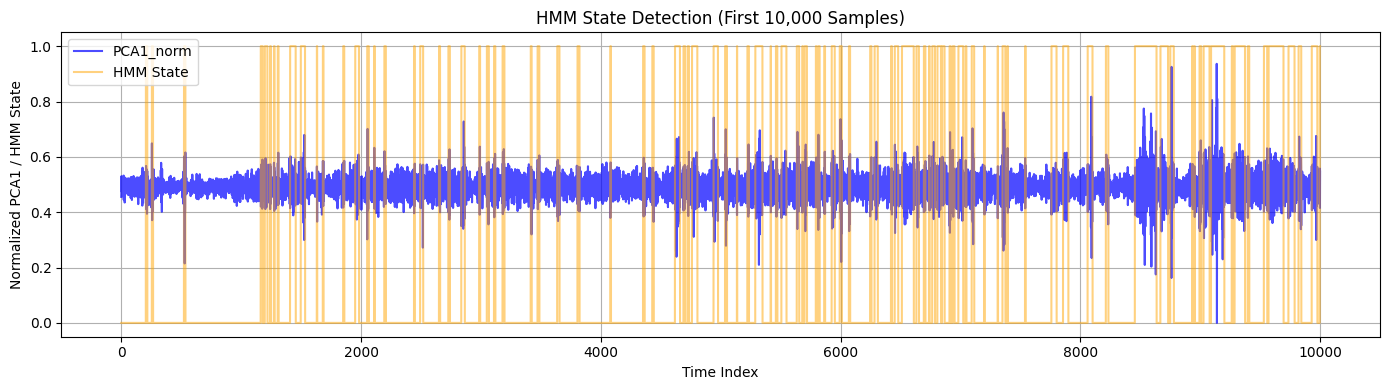


--- Aggressive Episode Summary (HMM) ---
Number of aggressive episodes: 385
Average episode duration (s): 0.5118181818181818
Max episode duration (s): 4.525

--- Overall Driving Behavior Summary ---
HMM-Based:
   Aggressive Driving:     16.91%
   Non-Aggressive Driving: 83.09%

Fuzzy Rule-Based Labels:
   Aggressive Driving:     7.87%
   Non-Aggressive Driving: 92.13%

 Combined Behavior Summary:
The driver exhibited aggressive behavior for approximately 
7.9% of the time (based on momentary spikes), 
while HMM detected 16.9% of the trip as part of 
385 aggressive episodes, with an average duration of 
0.5 sec (max: 4.5 sec).
HMM route behavior data saved with speed statistics


In [19]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from hmmlearn import hmm
from scipy.stats import percentileofscore
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# === STEP 1: Load + Filter ===
df = pd.read_csv(f"{prefix}_stop_cluster.csv")
df = df[df['cluster'] == -1].copy()  # Only use cluster == -1

# === STEP 2: Preprocessing ===
df['speed'] = df['Location_speed']
df['accel'] = df['Accel_vehicle_x']

# Compute jerk (change in acceleration)
dt = 1 / 40  # 40Hz
df['jerk'] = df['accel'].diff() / dt
df = df.dropna().reset_index(drop=True)

# === STEP 3: Compute Percentiles and Aggression Score ===
def get_percentiles(value, array):
    return percentileofscore(array, value, kind='rank') / 100

df['v_percentile'] = [get_percentiles(v, df['speed']) for v in df['speed']]
df['a_percentile'] = [get_percentiles(a, df['accel']) for a in df['accel']]
df['j_percentile'] = [get_percentiles(j, df['jerk']) for j in df['jerk']]

df['aggression_score'] = (
    0.2 * df['v_percentile'] +
    0.4 * df['a_percentile'] +
    0.4 * df['j_percentile']
)

# === STEP 4: Classification Labels ===
def get_class_label(v, a, j, jerk_array):
    a_critical = 0.008 * v + 0.1
    j_thresh = np.percentile(jerk_array, 90)
    return 1 if (a > a_critical and j > j_thresh) else 0

df['label'] = df.apply(
    lambda row: get_class_label(row['speed'], row['accel'], row['jerk'], df['jerk']),
    axis=1
)

print("\nLabel Distribution:")
print(df['label'].value_counts())

# === STEP 5: Train/Test Split ===
X = df[['speed', 'accel', 'jerk']]
y_reg = df['aggression_score']
y_clf = df['label']

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.3, random_state=42, stratify=y_clf)

# === STEP 6: Regression Model (Train/Test) ===
reg_model = RandomForestRegressor(random_state=42)
reg_model.fit(X_train, y_reg_train)
y_reg_pred = reg_model.predict(X_test)

print("\n--- Regression Evaluation (on Test Set) ---")
print("R²:", r2_score(y_reg_test, y_reg_pred))
print("MSE:", mean_squared_error(y_reg_test, y_reg_pred))

# === STEP 7: Classification Model (Train/Test) ===
clf_model = RandomForestClassifier(random_state=42)
clf_model.fit(X_train, y_clf_train)
y_clf_pred = clf_model.predict(X_test)

print("\n--- Classification Evaluation (on Test Set) ---")
print("Accuracy:", accuracy_score(y_clf_test, y_clf_pred))
print("F1 Score:", f1_score(y_clf_test, y_clf_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_clf_test, y_clf_pred))

# === STEP 8: HMM (Full Data) ===
pca = PCA(n_components=1)
df['PCA1'] = pca.fit_transform(df[['speed', 'accel', 'jerk']])
df['PCA1_norm'] = (df['PCA1'] - df['PCA1'].min()) / (df['PCA1'].max() - df['PCA1'].min())
obs = df['PCA1_norm'].values.reshape(-1, 1)

model = hmm.GaussianHMM(n_components=2, covariance_type='diag', n_iter=100, random_state=42)
model.fit(obs)
df['hmm_state'] = model.predict(obs)

# === STEP 9: Label HMM States as Aggressive/Non-Aggressive ===
state_scores = {}
for state in [0, 1]:
    state_scores[state] = df[df['hmm_state'] == state]['aggression_score'].mean()

if state_scores[0] > state_scores[1]:
    state_labels = {0: 'Aggressive', 1: 'Non-Aggressive'}
else:
    state_labels = {0: 'Non-Aggressive', 1: 'Aggressive'}

df['hmm_named'] = df['hmm_state'].map(state_labels)

print("\n--- HMM State Mapping ---")
print(state_labels)
print("\nHMM Named State Distribution vs True Labels:")
print(pd.crosstab(df['hmm_named'], df['label']))

# Convert categorical HMM prediction to binary (to match fuzzy label format)
# Map 'Aggressive' → 1, 'Non-Aggressive' → 0
hmm_pred_binary = df['hmm_named'].map({'Aggressive': 1, 'Non-Aggressive': 0})

# True labels from fuzzy rules
true_labels = df['label']

# Compute metrics
hmm_accuracy  = accuracy_score(true_labels, hmm_pred_binary)
hmm_precision = precision_score(true_labels, hmm_pred_binary)
hmm_recall    = recall_score(true_labels, hmm_pred_binary)
hmm_f1        = f1_score(true_labels, hmm_pred_binary)

# Print results
print("\nHMM vs Fuzzy Rule Metrics (scikit-learn)")
print(f"Accuracy : {hmm_accuracy:.4f}")
print(f"Precision: {hmm_precision:.4f}")
print(f"Recall   : {hmm_recall:.4f}")
print(f"F1 Score : {hmm_f1:.4f}")

# === STEP 10: Plot First 10,000 Points (PCA1 + HMM State) ===
N = 10000
plt.figure(figsize=(14, 4))
plt.plot(df['PCA1_norm'].values[:N], label='PCA1_norm', color='blue', alpha=0.7)
plt.plot(df['hmm_state'].values[:N], label='HMM State', color='orange', alpha=0.5)
plt.title("HMM State Detection (First 10,000 Samples)")
plt.xlabel("Time Index")
plt.ylabel("Normalized PCA1 / HMM State")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === STEP 11: Aggressive Episode Duration (HMM) ===
def find_episodes(state_sequence, target_state='Aggressive'):
    episodes = []
    start = None
    for i, state in enumerate(state_sequence):
        if state == target_state:
            if start is None:
                start = i
        else:
            if start is not None:
                end = i - 1
                duration = end - start + 1
                episodes.append((start, end, duration))
                start = None
    if start is not None:
        end = len(state_sequence) - 1
        duration = end - start + 1
        episodes.append((start, end, duration))
    return episodes

agg_episodes = find_episodes(df['hmm_named'].tolist(), target_state='Aggressive')
episodes_df = pd.DataFrame(agg_episodes, columns=['start_idx', 'end_idx', 'duration_samples'])
episodes_df['duration_seconds'] = episodes_df['duration_samples'] / 40  # 40Hz

print("\n--- Aggressive Episode Summary (HMM) ---")
print("Number of aggressive episodes:", len(episodes_df))
print("Average episode duration (s):", episodes_df['duration_seconds'].mean())
print("Max episode duration (s):", episodes_df['duration_seconds'].max())

# === STEP 12: Overall Behavior Percentages ===
total_samples = len(df)
hmm_agg_pct = (df['hmm_named'] == 'Aggressive').sum() / total_samples * 100
hmm_nonagg_pct = 100 - hmm_agg_pct

fuzzy_agg_pct = (df['label'] == 1).sum() / total_samples * 100
fuzzy_nonagg_pct = 100 - fuzzy_agg_pct

print("\n--- Overall Driving Behavior Summary ---")
print(f"HMM-Based:")
print(f"   Aggressive Driving:     {hmm_agg_pct:.2f}%")
print(f"   Non-Aggressive Driving: {hmm_nonagg_pct:.2f}%")
print(f"\nFuzzy Rule-Based Labels:")
print(f"   Aggressive Driving:     {fuzzy_agg_pct:.2f}%")
print(f"   Non-Aggressive Driving: {fuzzy_nonagg_pct:.2f}%")

summary = (
    f"The driver exhibited aggressive behavior for approximately \n"
    f"{fuzzy_agg_pct:.1f}% of the time (based on momentary spikes), \n"
    f"while HMM detected {hmm_agg_pct:.1f}% of the trip as part of \n"
    f"{len(episodes_df)} aggressive episodes, with an average duration of \n"
    f"{episodes_df['duration_seconds'].mean():.1f} sec (max: {episodes_df['duration_seconds'].max():.1f} sec)."
)

print("\n Combined Behavior Summary:\n" + summary)

# === STEP 13: Save HMM Route Data for Mapping WITH SPEED STATS ===

# Calculate speed statistics per behavior
speed_stats = df.groupby('hmm_named')['speed'].agg(
    min_speed='min',
    max_speed='max',
    avg_speed='mean'
).reset_index()

# Merge stats back to dataframe so every point knows its behavior speed stats
df_with_stats = df.merge(speed_stats, on='hmm_named', how='left')

# Prepare final dataframe for map
df_for_map = df_with_stats[[
    'Location_latitude',
    'Location_longitude',
    'hmm_named',
    'speed',
    'min_speed',
    'max_speed',
    'avg_speed'
]].dropna()

# Save
df_for_map.to_csv(f"{prefix}_hmm_route_behavior.csv", index=False)

print("HMM route behavior data saved with speed statistics")

# Final Output map

In [20]:
import pandas as pd
import folium

# === Load HMM Route Behavior Data ===
hmm_df = pd.read_csv(f"{prefix}_hmm_route_behavior.csv")
hmm_df.rename(columns={
    'Location_latitude': 'latitude',
    'Location_longitude': 'longitude'
}, inplace=True)

# === Load Behavior Markers (stoppage/pothole/bump) ===
merged_df = pd.read_csv(f"{prefix}_merged_stop_data_with_behavior.csv")

# === Initialize Folium Map ===
map_center = [hmm_df['latitude'].mean(), hmm_df['longitude'].mean()]
behavior_map = folium.Map(location=map_center, zoom_start=15)

# === Draw HMM-Based Route Segments ===
def get_hmm_color(behavior):
    return 'red' if behavior == 'Aggressive' else 'green'

for i in range(len(hmm_df) - 1):

    lat1, lon1 = hmm_df.iloc[i][['latitude', 'longitude']]
    lat2, lon2 = hmm_df.iloc[i + 1][['latitude', 'longitude']]
    behavior = hmm_df.iloc[i]['hmm_named']

    # Speed statistics (if present)
    min_speed = hmm_df.iloc[i]['min_speed'] if 'min_speed' in hmm_df.columns else None
    max_speed = hmm_df.iloc[i]['max_speed'] if 'max_speed' in hmm_df.columns else None
    avg_speed = hmm_df.iloc[i]['avg_speed'] if 'avg_speed' in hmm_df.columns else None

    # Safe formatting
    min_speed_text = f"{min_speed:.2f}" if pd.notna(min_speed) else "N/A"
    max_speed_text = f"{max_speed:.2f}" if pd.notna(max_speed) else "N/A"
    avg_speed_text = f"{avg_speed:.2f}" if pd.notna(avg_speed) else "N/A"

    popup_text = f"""
    <b>Driving Behavior:</b> {behavior}<br>
    <b>Latitude:</b> {lat1:.6f}<br>
    <b>Longitude:</b> {lon1:.6f}<br>
    <b>Min Speed:</b> {min_speed_text} km/h<br>
    <b>Max Speed:</b> {max_speed_text} km/h<br>
    <b>Avg Speed:</b> {avg_speed_text} km/h
    """

    popup = folium.Popup(popup_text, max_width=300, sticky=True)

    folium.PolyLine(
        locations=[(lat1, lon1), (lat2, lon2)],
        color=get_hmm_color(behavior),
        weight=5,
        opacity=0.7,
        popup=popup
    ).add_to(behavior_map)

# === Add Start Marker ===
folium.Marker(
    location=[hmm_df.iloc[0]['latitude'], hmm_df.iloc[0]['longitude']],
    popup="Start",
    icon=folium.Icon(color='blue')
).add_to(behavior_map)

# === Add End Marker ===
folium.Marker(
    location=[hmm_df.iloc[-1]['latitude'], hmm_df.iloc[-1]['longitude']],
    popup="End",
    icon=folium.Icon(color='purple')
).add_to(behavior_map)

# === Add Markers for Stoppage/Pothole/Bump Behavior ===
color_map = {
    'pothole': 'red',
    'bump': 'blue',
    'stoppage': 'green',
    'unknown': 'gray'
}

for _, row in merged_df.iterrows():

    popup_text = (
        f"<b>Cluster:</b> {int(row['cluster'])}<br>"
        f"<b>Lat:</b> {row['latitude']:.6f}<br>"
        f"<b>Lon:</b> {row['longitude']:.6f}<br>"
        f"<b>Mean Speed:</b> {row['mean_speed']:.2f} km/h<br>"
        f"<b>Min Speed:</b> {row['min_speed']:.2f} km/h<br>"
        f"<b>Max Speed:</b> {row['max_speed']:.2f} km/h<br>"
        f"<b>Behavior:</b> {row['behavior']}"
    )

    color = color_map.get(row['behavior'], 'gray')

    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=folium.Popup(popup_text, max_width=300, sticky=True),
        icon=folium.Icon(color=color, icon='circle')
    ).add_to(behavior_map)

# === Add Legend ===
legend_html = """
<div style="
position: fixed;
bottom: 50px; left: 50px; width: 220px;
background-color: white;
border:2px solid grey;
z-index:9999;
font-size:14px;
padding: 10px;
">

<b>Map Legend</b><br><br>

<b>Route Behavior</b><br>
<span style="color:red;">&#9632;</span> Aggressive Driving<br>
<span style="color:green;">&#9632;</span> Normal Driving<br><br>

<b>Road Events</b><br>
<span style="color:red;">&#9679;</span> Pothole<br>
<span style="color:blue;">&#9679;</span> Bump<br>
<span style="color:green;">&#9679;</span> Stoppage<br>
<span style="color:gray;">&#9679;</span> Unknown<br><br>

<b>Trip Markers</b><br>
<span style="color:blue;">&#9679;</span> Start<br>
<span style="color:purple;">&#9679;</span> End

</div>
"""

behavior_map.get_root().html.add_child(folium.Element(legend_html))

# === Save Final Map ===
final_map_name = f"{prefix}_combined_driver_behavior_map.html"
behavior_map.save(final_map_name)

print(f"Combined map saved as: {final_map_name}")

Combined map saved as: Normal_24-6-25_naroda-to-dau_combined_driver_behavior_map.html
